In [1]:
from src import *

In [2]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

In [3]:
spade_mean = {3: [], 5: []}
spade_var = {3: [], 5: []}
spade_f = {3: [], 5: []}


di_mean = {3: [], 5: []}
di_var = {3: [], 5: []}
di_f = {3: [], 5: []}


for a in (3, 5):
    for f_ in np.linspace(0.1, 0.4, 61):
        f = np.round(f_, 5)
        spade_c = LoadEstimates(f'data/ideal/spade_{a}px_f{f}_d0.npz')
        di_c = LoadEstimates(f'data/ideal/di_{a}px_f{f}_d0.npz')

        spade_f[a].append(spade_c.metadata.ground_truth)
        spade_mean[a].append(spade_c.estimates.mean())
        spade_var[a].append(spade_c.estimates.var(ddof=1) * spade_c.photons)

        di_f[a].append(di_c.metadata.ground_truth)
        di_mean[a].append(di_c.estimates.mean())
        di_var[a].append(di_c.estimates.var(ddof=1) * di_c.photons)

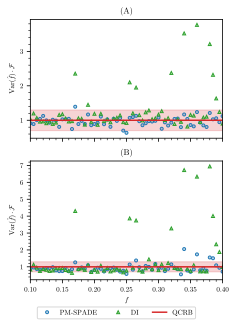

In [38]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(width, width * 1.3), sharex=True)

for ax in (ax1, ax2):
    a = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 61)
    fi = DI.ApproxCFI(DMD.A(a)) * np.ones(61)

    line1, = ax.plot(spade_f[a], spade_var[a] * fi, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax.plot(di_f[a], di_var[a] * fi,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))

    line3, = ax.plot(x_axis, np.ones(61), red)

    ax.set_ylabel(r'${\rm Var}(\hat{f})\cdot \mathcal{F}$')
    # ax.set_title(rf'$A = {np.round(DMD.A(a) / DI.SIGMA, 2)}\sigma$')

    ax.fill_between(x_axis, 0.7 * np.ones(61), 1.3 * np.ones(61), color=red, alpha=0.2)
ax1.set_title('(A)')
ax2.set_title('(B)')

for ax in (ax1, ax2):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax2.set_xlabel(r'$f$')
ax1.set_yticks(np.arange(1, 4))
ax2.set_yticks(np.arange(1, 8))

fig.legend([line1, line2, line3], ['PM-SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('ideal.pdf')
plt.show()

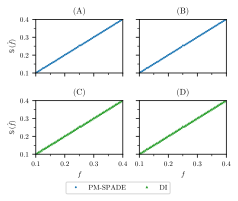

In [36]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(width, width*0.8), sharex=True, sharey=True)

for a in (3, 5):
    if a == 3:
        ax_spade = ax1
        ax_di = ax3
    else:
        ax_spade = ax2
        ax_di = ax4

    line1, = ax_spade.plot(spade_f[a], spade_mean[a], 
                    marker='o', linestyle='', markersize=1,
                    markeredgecolor=c1, markerfacecolor=c1)

    line2, = ax_di.plot(di_f[a], di_mean[a],
                    marker='^', linestyle='', markersize=1,
                    markeredgecolor=c2, markerfacecolor=c1)


for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlim(0.1, 0.4)
    ax.set_ylim(0.1, 0.4)
    ax.set_xticks(np.linspace(0.1, 0.4, 4))
    ax.set_yticks(np.linspace(0.1, 0.4, 4))

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))


for ax in (ax3, ax4):
    ax.set_xlabel(r'$f$')

for ax in (ax1, ax3):
    ax.set_ylabel(r'${\rm \mathbb{S\,}}(\hat f)$')


ax1.set_title(rf'(A)')
ax2.set_title(rf'(B)')

ax3.set_title(rf'(C)')
ax4.set_title(rf'(D)')

fig.legend([line1, line2], ['PM-SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('mean.pdf')
plt.show()